In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import plotly.graph_objects as go

In [2]:
def fetch_data(tickers : list[str], start_date : datetime, end_date : datetime) -> dict[str, pd.DataFrame]:
    m = {}
    for ticker in tickers:
        print(f"Fetching data for {ticker}...")
        try:
            stock = yf.Ticker(ticker)
            df = stock.history(start=start_date, end=end_date)
            df.columns = df.columns.str.lower()  # Convert column names to lowercase
            m[ticker] = df
        except Exception as e:
            print(f"Error fetching data for {ticker}: {e}")
    return m

In [3]:
def _calculate_rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Relative Strength Index"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss.replace(0, 1)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def _calculate_atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    """Calculate Average True Range"""
    high_low = df['high'] - df['low']
    high_close = np.abs(df['high'] - df['close'].shift())
    low_close = np.abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    atr = true_range.rolling(period).mean()
    return atr

In [4]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Add comprehensive technical indicators - NO LOOK-AHEAD BIAS"""
    # Price-based indicators
    df['returns'] = df['close'].pct_change()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    
    # Moving averages (use only past data)
    for window in [5, 10, 20, 50, 200]:
        df[f'sma_{window}'] = df['close'].rolling(window).mean()
        df[f'ema_{window}'] = df['close'].ewm(span=window, adjust=False).mean()
    
    # Volatility (use only past data)
    for window in [5, 10, 20, 60]:
        df[f'volatility_{window}'] = df['returns'].rolling(window).std()
        df[f'atr_{window}'] = _calculate_atr(df, window)
    
    # Momentum indicators
    df['rsi_14'] = _calculate_rsi(df['close'], 14)
    df['rsi_28'] = _calculate_rsi(df['close'], 28)
    
    # MACD
    exp1 = df['close'].ewm(span=12, adjust=False).mean()
    exp2 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = exp1 - exp2
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    
    # Bollinger Bands
    for window in [20]:
        sma = df['close'].rolling(window).mean()
        std = df['close'].rolling(window).std()
        df[f'bb_upper_{window}'] = sma + (2 * std)
        df[f'bb_lower_{window}'] = sma - (2 * std)
        df[f'bb_width_{window}'] = (df[f'bb_upper_{window}'] - df[f'bb_lower_{window}']) / sma
        df[f'bb_position_{window}'] = (df['close'] - df[f'bb_lower_{window}']) / (df[f'bb_upper_{window}'] - df[f'bb_lower_{window}'])
    
    # Volume indicators
    df['volume_sma_20'] = df['volume'].rolling(20).mean()
    df['volume_ratio'] = df['volume'] / df['volume_sma_20'].replace(0, 1)
    df['obv'] = (np.sign(df['returns']) * df['volume']).fillna(0).cumsum()
    
    # Price patterns
    df['high_low_ratio'] = df['high'] / df['low'].replace(0, 1)
    df['close_open_ratio'] = df['close'] / df['open'].replace(0, 1)
    
    # Momentum
    for period in [5, 10, 20]:
        df[f'momentum_{period}'] = df['close'].pct_change(period)
    
    return df

In [5]:
tickers = ['AAPL', 'MSFT', 'JPM', 'GS', 'JNJ']

In [6]:
end_date = datetime.now()
YEARS = 2
start_date = end_date - timedelta(days=365 * YEARS)

end_date_str = end_date.strftime('%Y-%m-%d')
start_date_str = start_date.strftime('%Y-%m-%d')

In [7]:
stocks_data = fetch_data(tickers, start_date_str, end_date_str)
for ticker, df in stocks_data.items():
    print(f"Adding technical indicators for {ticker}...")
    stocks_data[ticker] = add_technical_indicators(df)


Fetching data for AAPL...
Fetching data for MSFT...
Fetching data for JPM...
Fetching data for GS...
Fetching data for JNJ...
Adding technical indicators for AAPL...
Adding technical indicators for MSFT...
Adding technical indicators for JPM...
Adding technical indicators for GS...
Adding technical indicators for JNJ...


In [8]:
def plot_technical_indicators(df: pd.DataFrame, ticker: str):
    """Plot price and key technical indicators"""
    plt.figure(figsize=(14, 10))
    
    # Price and Moving Averages
    plt.subplot(2, 1, 1)
    plt.plot(df['close'], label='Close Price', color='blue')
    plt.plot(df['sma_20'], label='SMA 20', color='orange')
    plt.plot(df['sma_50'], label='SMA 50', color='green')
    plt.title(f'{ticker} Price and Moving Averages')
    plt.legend()

    # Bollinger Bands
    plt.fill_between(df.index, df['bb_lower_20'], df['bb_upper_20'], color='lightgray', alpha=0.5, label='Bollinger Bands')

    # Volume Bar Bars
    plt.subplot(2, 1, 2)
    plt.bar(df.index, df['volume'], label='Volume', color='lightblue', alpha=0.5)
    plt.title(f'{ticker} Volume and Bollinger Bands')
    plt.legend()

    
    plt.tight_layout()
    plt.show()

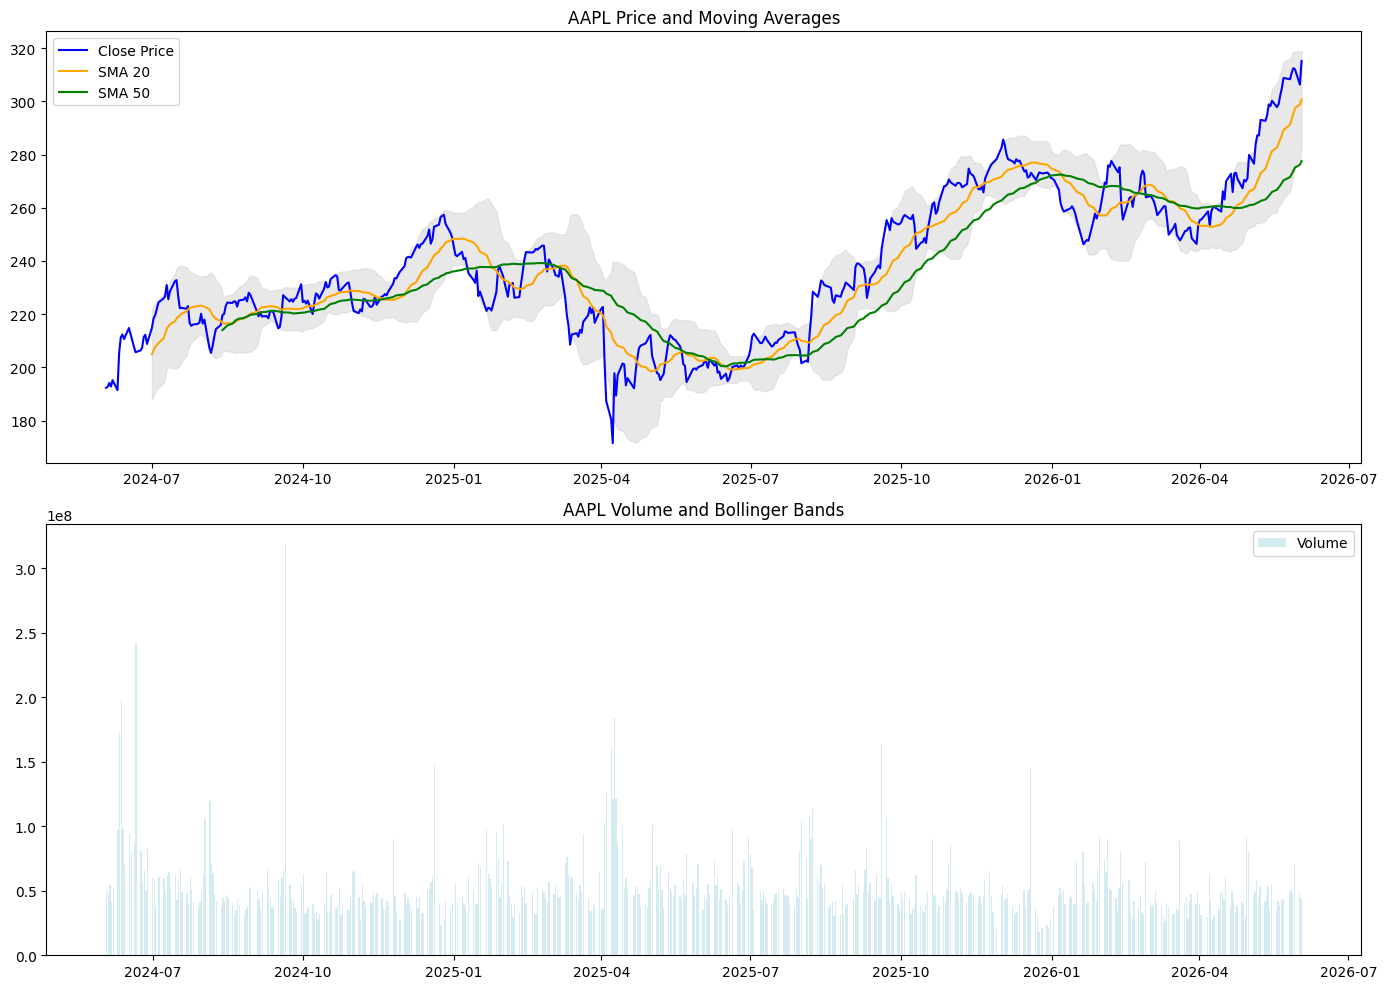

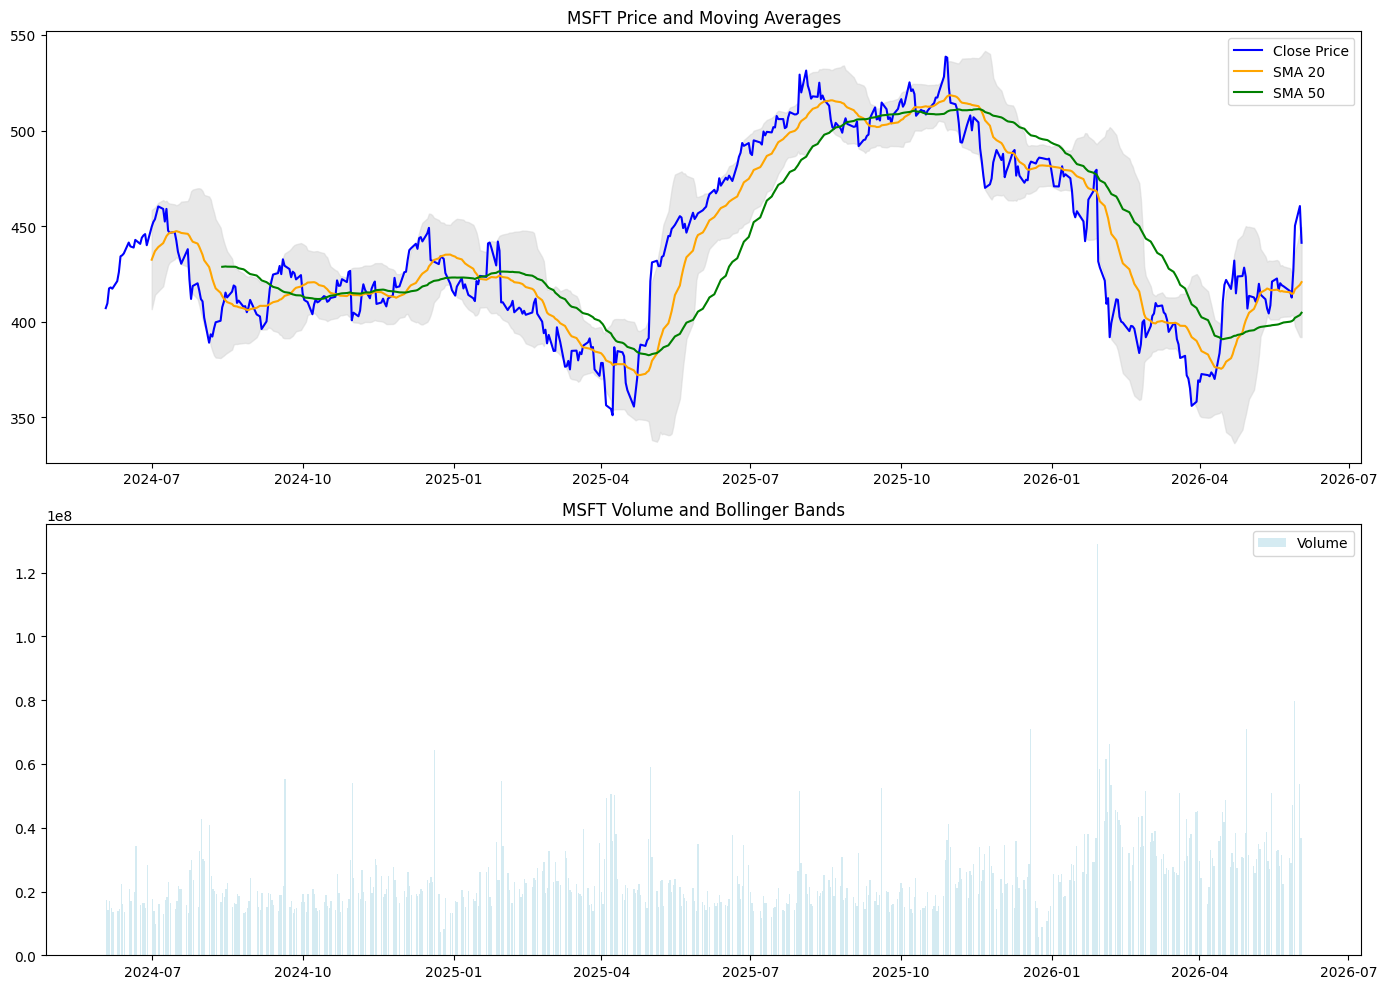

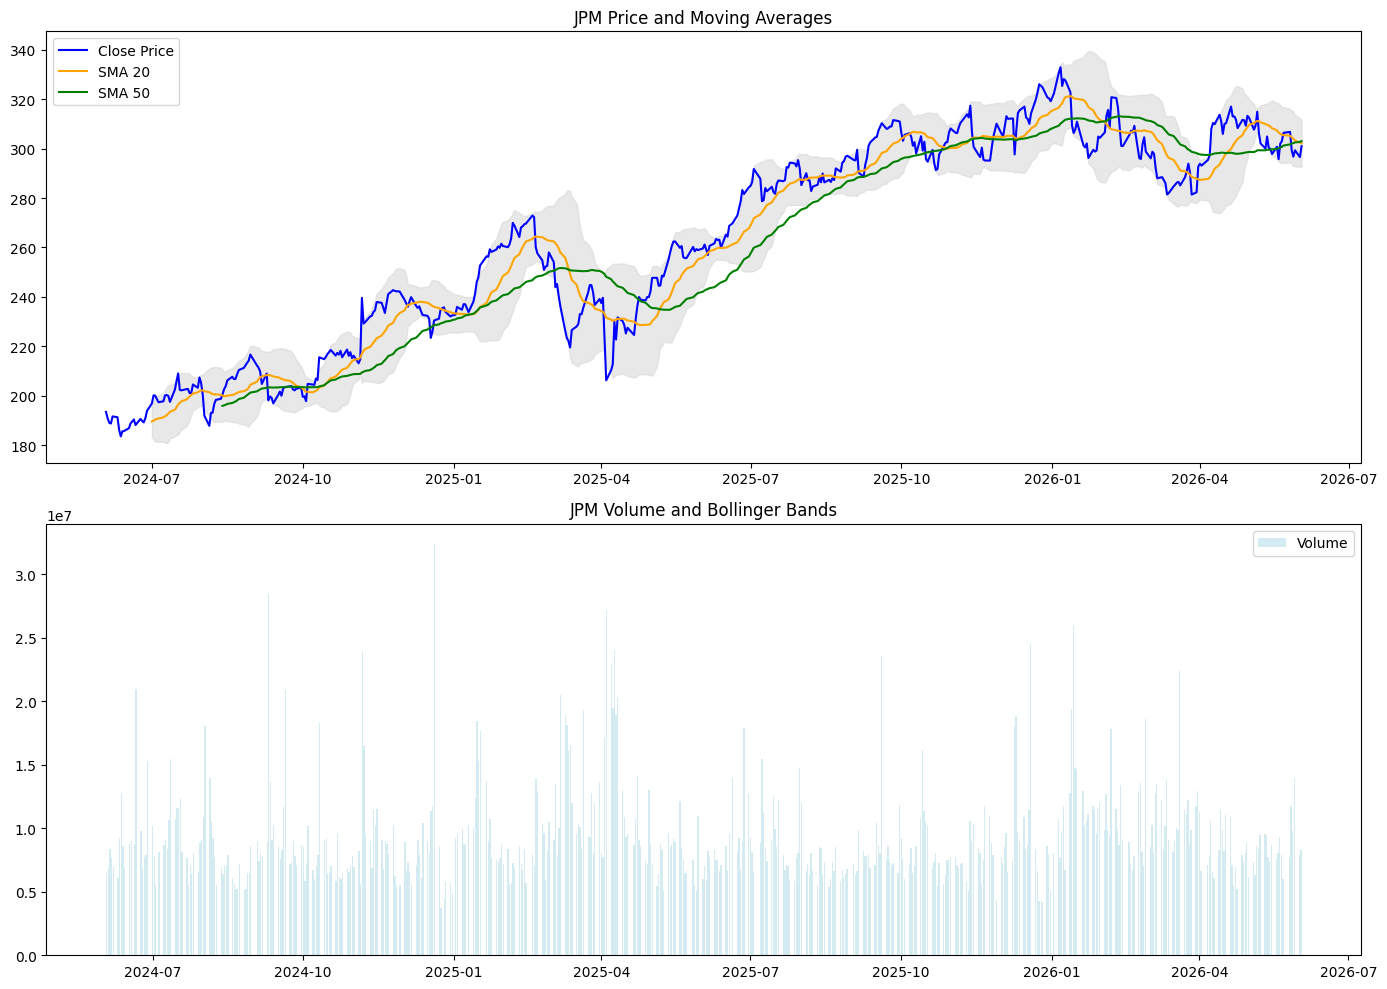

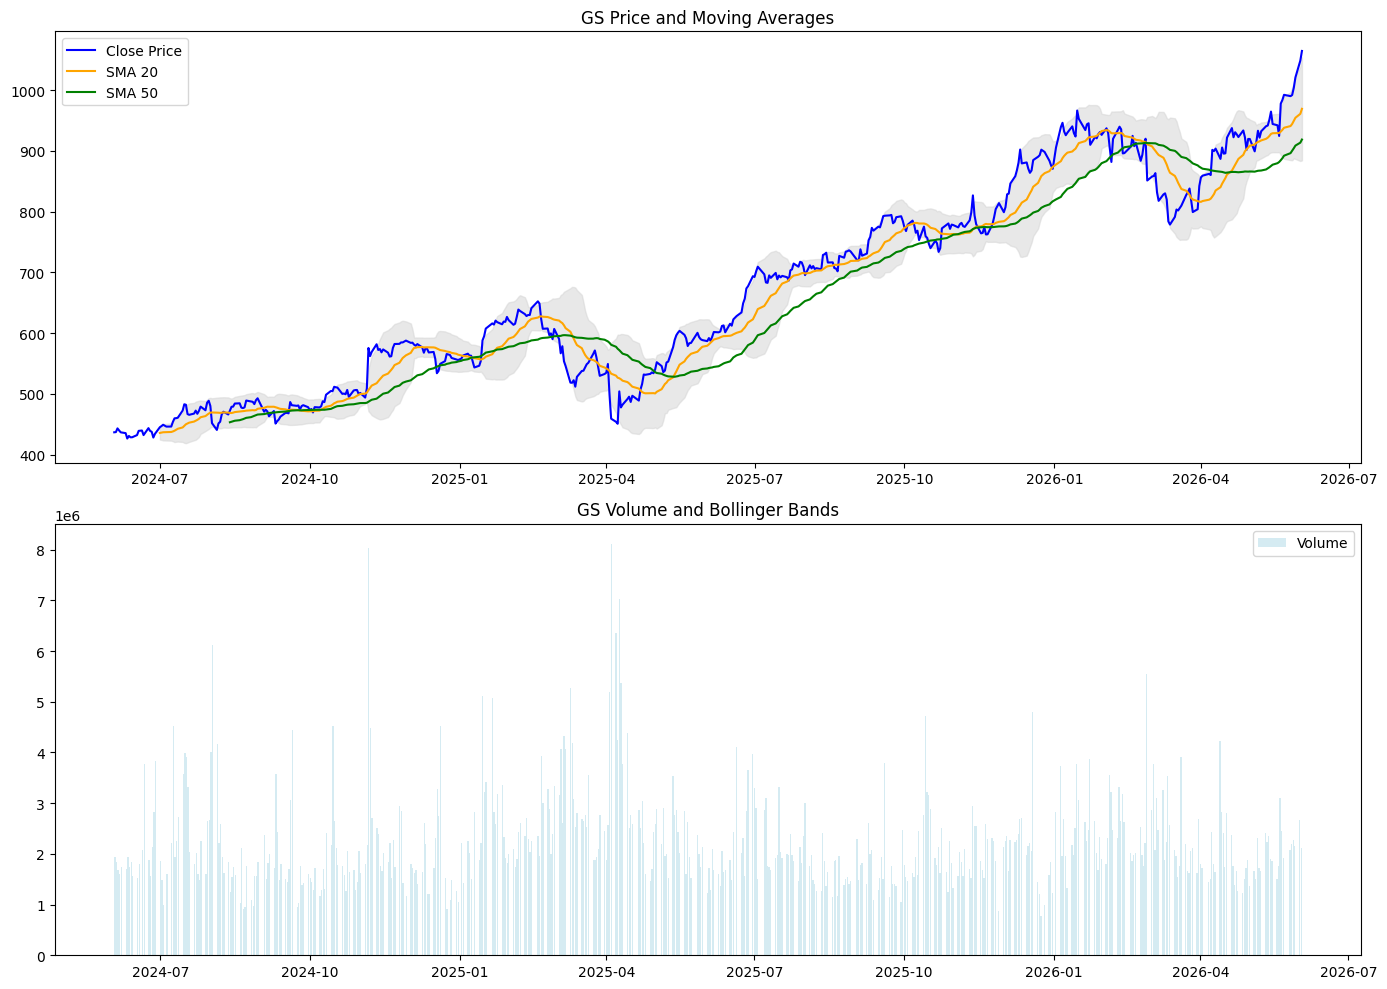

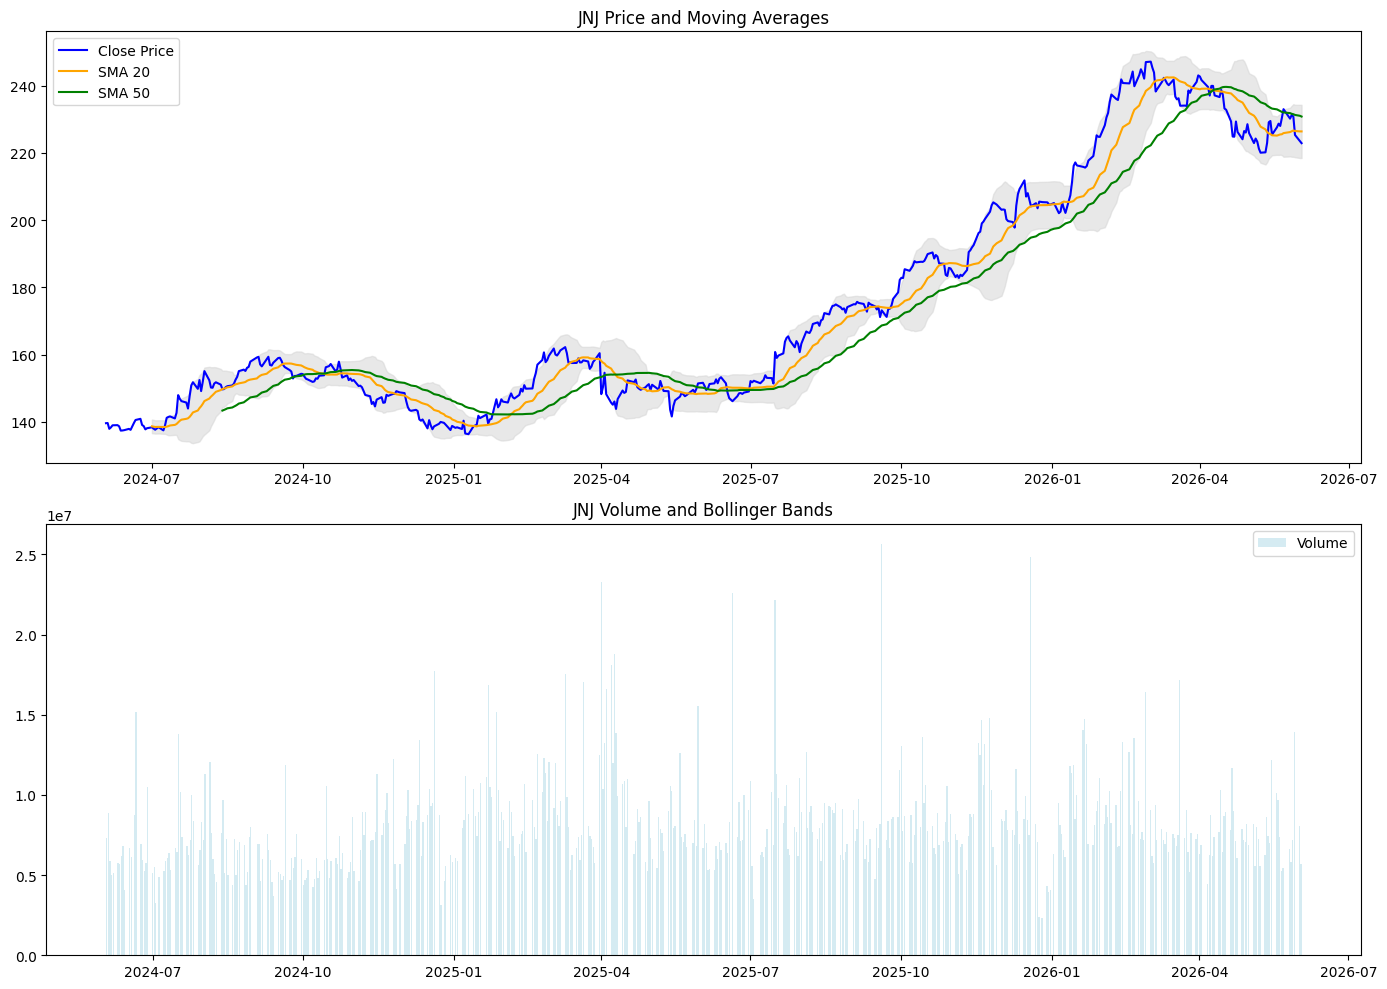

In [9]:
for ticker in tickers:
    plot_technical_indicators(stocks_data[ticker], ticker)

In [10]:
def plot_ohlcv_bars(df: pd.DataFrame, ticker: str):
    """Plot OHLCV bars"""
    df = df.reset_index()
    # Plot SMA 20 SMA 50 and Bollinger Bands
    

    fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                    open=df['open'],
                    high=df['high'],
                    low=df['low'],
                    close=df['close'],
                    name='OHLC')])
    
    fig.add_trace(go.Scatter(
        x=df['Date'], 
        y=df['sma_20'], 
        mode='lines', 
        name='20 SMA',
        line=dict(color='orange', width=1.5)
    ))
    fig.add_trace(go.Scatter(
        x=df['Date'], 
        y=df['sma_50'], 
        mode='lines', 
        name='50 SMA',
        line=dict(color='blue', width=1.5)
    ))
    fig.update_layout(title=f'{ticker} OHLCV Bars', xaxis_title='Date', yaxis_title='Price', xaxis_rangeslider_visible=False, yaxis2=dict(title='Volume'))
    fig.show()

In [11]:
for ticker in tickers:
    plot_ohlcv_bars(stocks_data[ticker], ticker)